####Предварительная обработка датасета

In [1]:
import pandas as pd

Модель обучается на датасете с характеристиками ответов на тест СВБ 38 пациентов

In [9]:
info = pd.read_csv("info.csv", encoding='cp1251', sep=";") #считывается датафрейм с данными пациентов

In [10]:
info.head(3)

,GROUP,avg_wc,avg_rep,percentage,irr,avg_each_cluster_len,cl1,cl2,cl3_n,common_l,cl_norm,sw_norm
0,1,15.333333,15.666667,0.020833,0.0,3.615385,3.5,2.5,6,4.333333,27.659574,21.276596
1,1,15.333333,15.333333,0.000000,0.0,1.840000,7.5,6.5,10,8.333333,54.347826,47.826087
2,1,17.666667,18.333333,0.039216,0.0,2.291667,8.5,7.5,7,8.000000,43.636364,38.181818


Выделение целевой переменной, разделение на тестовую и обучающую выборку

In [11]:
X = info.drop('GROUP', axis=1)
y = info['GROUP']

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=39, stratify=y)

Нормализация данных с помощью StandartScaler

In [13]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#датафреймы для последующей интерпретазции значимости признаков
X_train_scaled_2 = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_2 = pd.DataFrame(X_test_scaled, columns=X_test.columns)

Модель логистической регрессии, группа 1 соответствует группе пациентов с субъективным когнитивным снижением, группа 2 - группе пациентов с мягким когнитивным снижением

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


model = LogisticRegression(C=0.1, max_iter=250)
model.fit(X_train_scaled_2, y_train)

y_pred = model.predict(X_test_scaled_2)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.75      0.60      0.67         5
           2       0.75      0.86      0.80         7

    accuracy                           0.75        12
   macro avg       0.75      0.73      0.73        12
weighted avg       0.75      0.75      0.74        12



Коэффициенты признаков (значимость параметров) модели

In [15]:
weights = pd.DataFrame({
    'Feature': X_train_scaled_2.columns,
    'Coefficient': model.coef_[0]
})


weights['Abs_Coefficient'] = weights['Coefficient'].abs()
weights = weights.sort_values(by='Abs_Coefficient', ascending=False)

weights[['Feature', 'Coefficient']]

,Feature,Coefficient
2,percentage,0.156726
5,cl1,-0.114513
6,cl2,-0.114513
7,cl3_n,0.082909
0,avg_wc,-0.072343
8,common_l,-0.060277
1,avg_rep,-0.048301
4,avg_each_cluster_len,-0.031843
10,sw_norm,-0.028110
3,irr,0.020980


Интерпретация коэффицентов признаков проведена в тексте курсовой работы.

*Признаки* (в том же порядке):

*  percentage of word repetitions
*  avg. length of categories 1, 2 (clusters)
*  number of switches in categories 1, 2
*  length of category 3 (clusters)
*  avg. length of a response (words)
*  avg. length of a response (clusters)
*  avg. length of a response + rep (words)
*  avg. length of a cluster
*  num. of switches per 100 words
*  sum. of irrelevant words
*  num. of clusters per 100 words

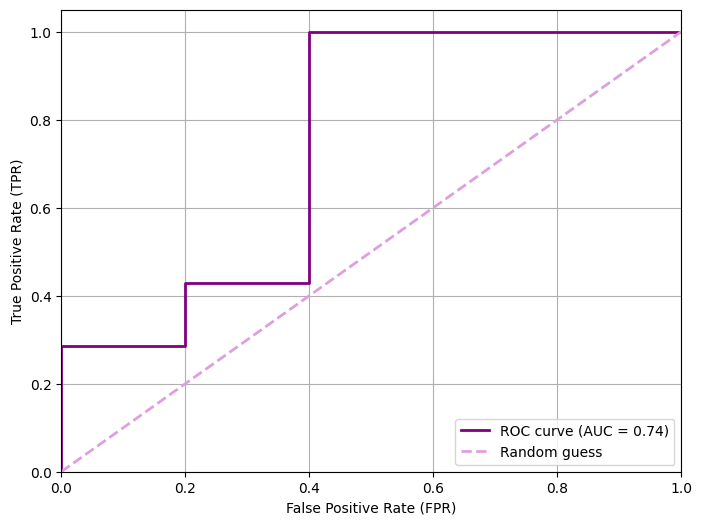

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

y_probs = model.predict_proba(X_test_scaled_2)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs, pos_label=2)

roc_auc = roc_auc_score(y_test, y_probs)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='plum', lw=2, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()